In [42]:
import pandas as pd

In [43]:
df=pd.read_csv(r"C:\Users\Leo\Downloads\archive (10)\dataset.csv")

In [44]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [45]:
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [46]:
df['Target'] = df['Target'].apply(
    lambda x: 1 if x == 'Dropout' else 0
)

In [47]:
columns = [
    'Age at enrollment',
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Gender',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Target'
]

df = df[columns]

In [48]:
df.isnull().sum()

Age at enrollment                      0
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Gender                                 0
Curricular units 1st sem (approved)    0
Curricular units 1st sem (grade)       0
Curricular units 2nd sem (approved)    0
Curricular units 2nd sem (grade)       0
Target                                 0
dtype: int64

In [49]:
df['Target'].value_counts()

Target
0    3003
1    1421
Name: count, dtype: int64

In [50]:
df['Target'].value_counts(normalize=True) * 100

Target
0    67.879747
1    32.120253
Name: proportion, dtype: float64

In [51]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Age at enrollment                    4424 non-null   int64  
 1   Debtor                               4424 non-null   int64  
 2   Tuition fees up to date              4424 non-null   int64  
 3   Scholarship holder                   4424 non-null   int64  
 4   Gender                               4424 non-null   int64  
 5   Curricular units 1st sem (approved)  4424 non-null   int64  
 6   Curricular units 1st sem (grade)     4424 non-null   float64
 7   Curricular units 2nd sem (approved)  4424 non-null   int64  
 8   Curricular units 2nd sem (grade)     4424 non-null   float64
 9   Target                               4424 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 345.8 KB


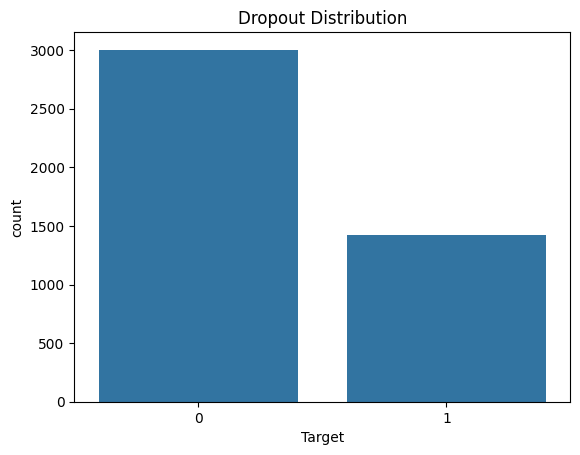

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Target', data=df)
plt.title('Dropout Distribution')
plt.show()

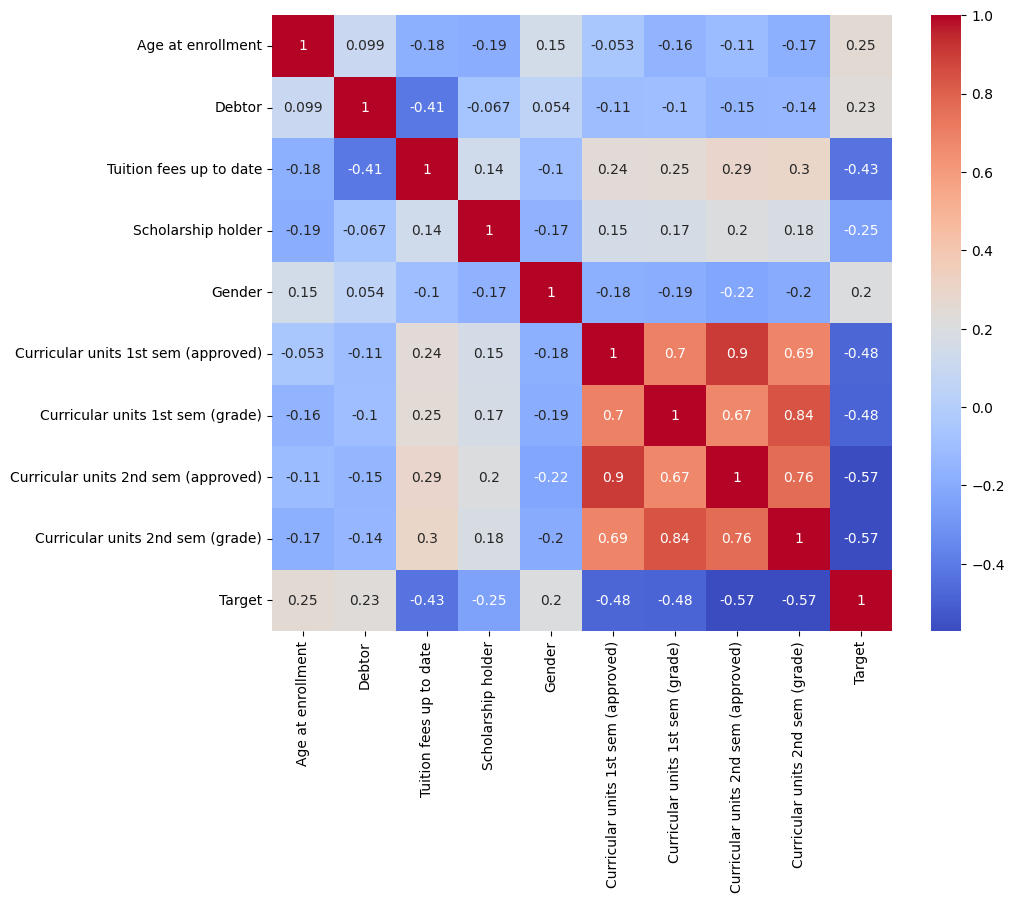

In [53]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [54]:
corr = df.corr()['Target'].sort_values(ascending=False)
print(corr)

Target                                 1.000000
Age at enrollment                      0.254215
Debtor                                 0.229407
Gender                                 0.203983
Scholarship holder                    -0.245354
Tuition fees up to date               -0.429149
Curricular units 1st sem (approved)   -0.479112
Curricular units 1st sem (grade)      -0.480669
Curricular units 2nd sem (approved)   -0.569500
Curricular units 2nd sem (grade)      -0.571792
Name: Target, dtype: float64


In [55]:
X = df.drop('Target', axis=1)
y = df['Target']

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [58]:
y_pred = model.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8598870056497175


In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[538  63]
 [ 61 223]]


In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       601
           1       0.78      0.79      0.78       284

    accuracy                           0.86       885
   macro avg       0.84      0.84      0.84       885
weighted avg       0.86      0.86      0.86       885



In [62]:
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8598870056497175
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       601
           1       0.78      0.79      0.78       284

    accuracy                           0.86       885
   macro avg       0.84      0.84      0.84       885
weighted avg       0.86      0.86      0.86       885

[[538  63]
 [ 61 223]]


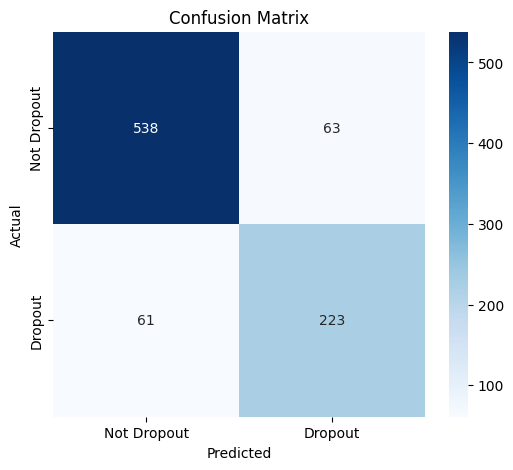

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Dropout', 'Dropout'],
    yticklabels=['Not Dropout', 'Dropout']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [64]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                               Feature  Importance
7  Curricular units 2nd sem (approved)    0.734104
2              Tuition fees up to date    0.150046
0                    Age at enrollment    0.055938
5  Curricular units 1st sem (approved)    0.024124
8     Curricular units 2nd sem (grade)    0.015439
1                               Debtor    0.012851
3                   Scholarship holder    0.005521
6     Curricular units 1st sem (grade)    0.001477
4                               Gender    0.000501


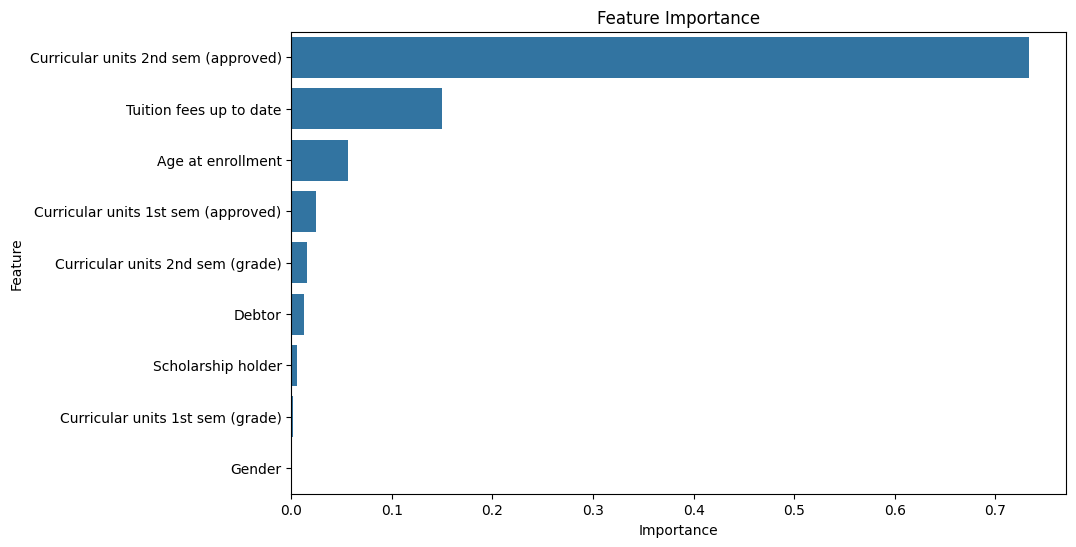

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')
plt.show()

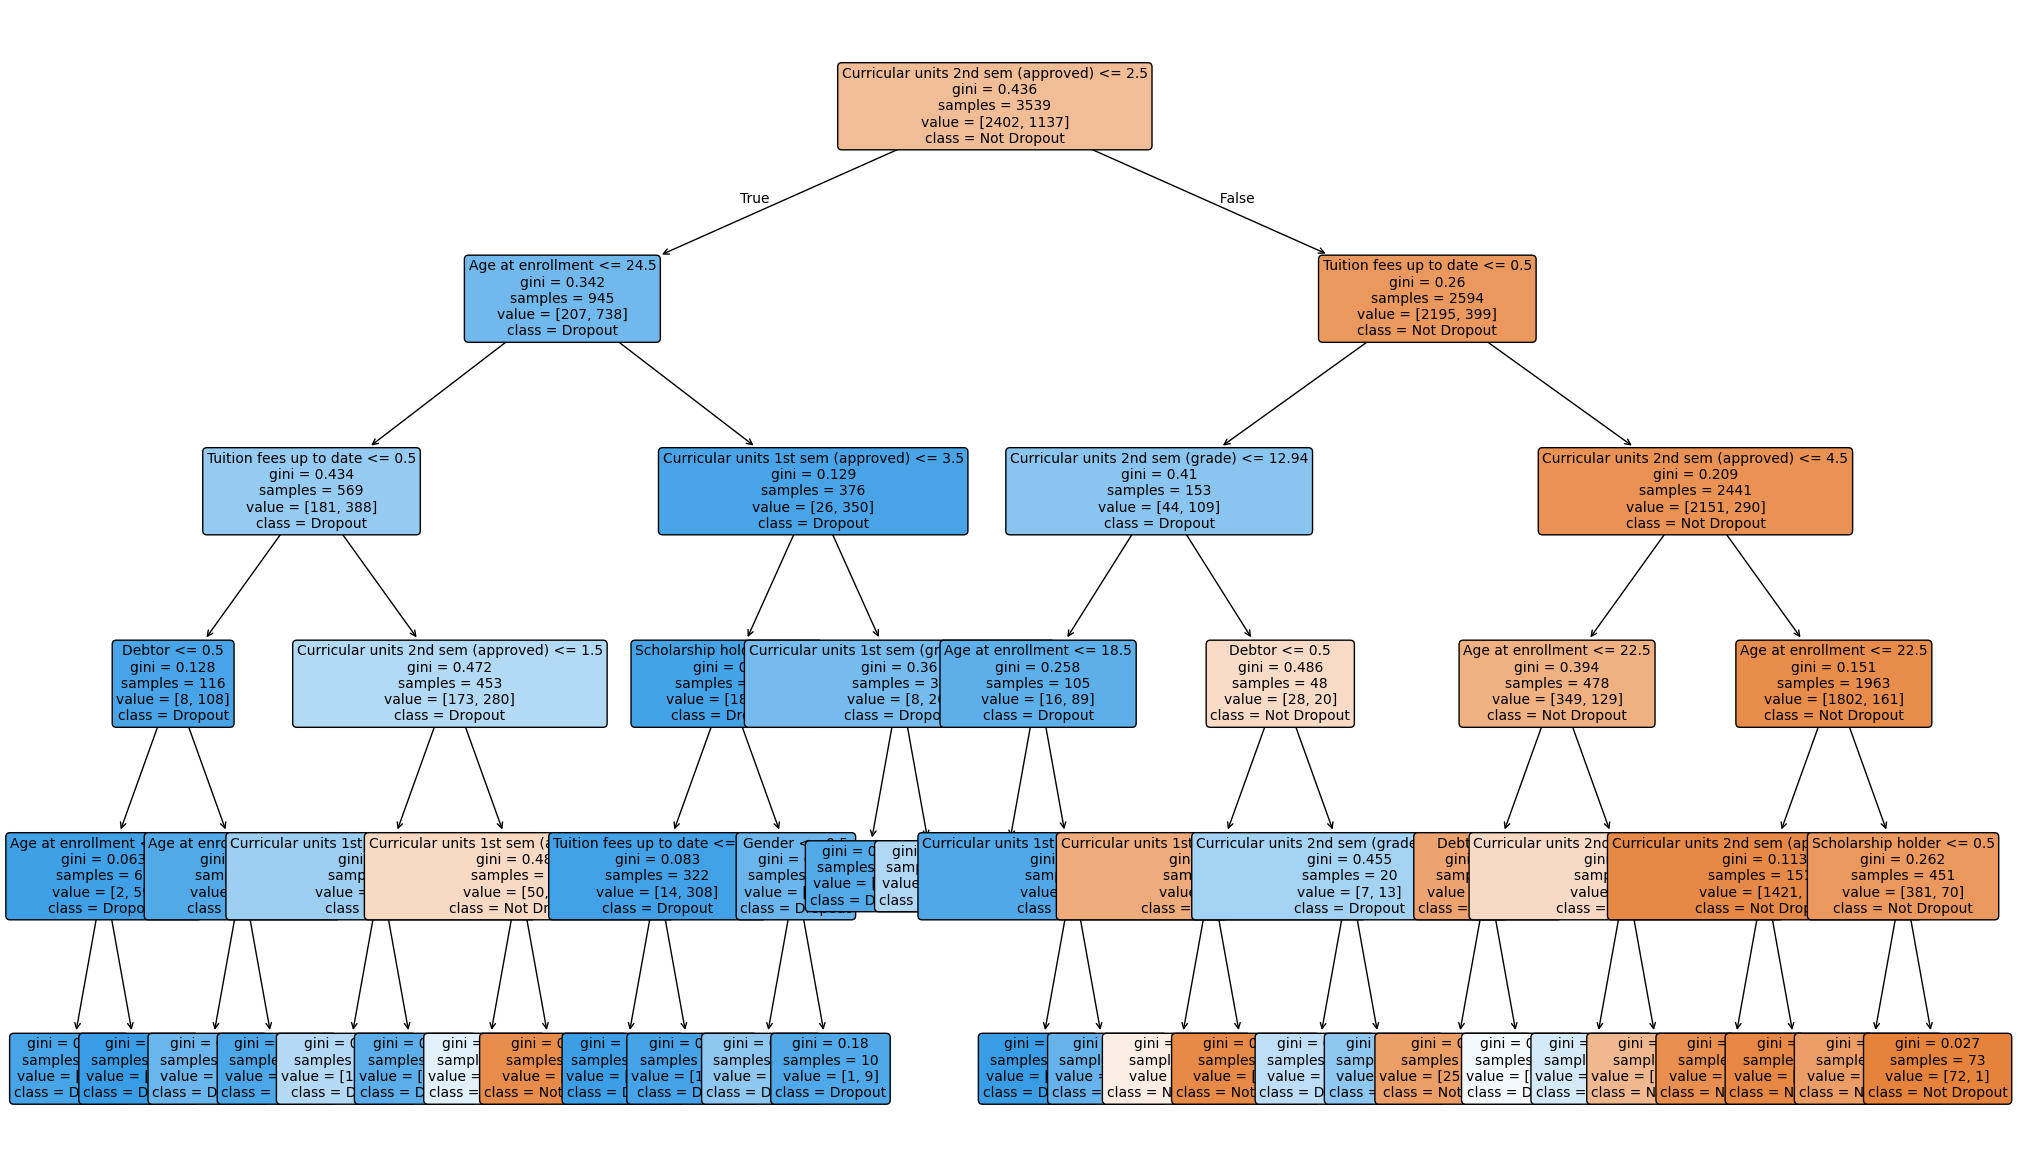

In [66]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,15))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Dropout', 'Dropout'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

In [71]:
import pickle

pickle.dump(
    model,
    open("decision_tree.pkl", "wb")
)